# Project 1 - E-commerce

## Business problem

A global online retail company is struggling to understand customer behavior, identify high-value customers, 
and uncover product purchasing patterns. This lack of insight results in inefficient marketing strategies, 
poor customer targeting, and missed opportunities for cross-selling and revenue optimization.

## Objectives

#### 1) Customer Segmentation (Understand customers)

To segment customers into distinct groups based on purchasing behavior using recency, frequency, and monetary (RFM) metrics 
in order to identify meaningful customer segments for targeted business strategies.

To derive insights including:

* Customer types (frequent, one-time, inactive, bulk, seasonal)
* Behavioral patterns (high-frequency vs high-spend, low-frequency vs high-spend)
* Customer lifecycle stages (recent, active, inactive)

Business impact:

This segmentation will enable targeted marketing, improved customer retention, and better resource allocation

#### 2) Customer Value Prediction (Predict customers)

To develop a classification model that predicts whether a customer is high-value or low-value based on purchasing behavior, leveraging 
insights derived from customer segmentation to enable targeted marketing and optimized resource allocation.

#### 3) Market Basket Analysis (Understand products)

To identify relationships between products using association rule mining, in order to discover frequently co-purchased items 
and support product recommendation and cross-selling strategies.



#### Libraries

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#### Data Load

In [2]:
ecommerce_df = pd.read_csv("E-commerce.csv")

In [3]:
ecommerce_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#### Data Understanding

This is a transactional level data of customer purchases from an online retail store

* InvoiceNo - A nominal 6-digit unique transaction number, c-cancellation

* StockCode (Product Item Code) -  A nominal 5-digit unique number for each distinct product

* Description - Product name

* Quantity - Quantities purchased per transaction

* InvoiceDate (Invoice Date Time) - The date and time of transaction 

* UnitPrice - Product price per unit in sterling

* CustomerID - A nominal 5-digit unique number for each customer

* Country - Country of the customer

#### Renaming columns for clarity

In [4]:
ecommerce_df.rename(columns={'StockCode':'ProductCode',
                             'Description': 'ProductName'}, inplace=True)

In [5]:
ecommerce_df.head()

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Initial Data Exploration and Handling

In [6]:
ecommerce_df.shape

(541909, 8)

The dataset contains 5,41,909 rows and 8 columns

In [7]:
ecommerce_df.isnull().sum()

InvoiceNo           0
ProductCode         0
ProductName      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### Validating missing values of ProductName in CustomerID

In [8]:
ecommerce_df[
    ecommerce_df['ProductName'].isnull() &
    ecommerce_df['CustomerID'].notnull()
].shape

(0, 8)

In [9]:
ecommerce_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   ProductCode  541909 non-null  object 
 2   ProductName  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


`ISSUES`

1) InvoiceDate is stored as object
2) CustomerID has missing values
3) CustomerID is stored as float
4) ProductName has missing values

#### Converting InvoiceDate to DateTime

In [10]:
ecommerce_df['InvoiceDate'] = pd.to_datetime(ecommerce_df['InvoiceDate'])

#### Handling Missing CustomerID 

In [11]:
ecommerce_df['CustomerID'].isnull().sum()

np.int64(135080)

`OBSERVATION`

The CustomerID column contains 1,35,080 missing values.

#### Creating new dataframe

In [12]:
ecommerce_cleaned = ecommerce_df.dropna(subset=['CustomerID']).copy()

`ACTION`

Rows with missing CustomerID values were removed by creating a new cleaned dataset.

`REASON`

Since the objective of the project focuses on customer purchasing behavior,
a valid customer identifier is<br> essential for analysis.
Rows without CustomerID cannot be used for customer-level insights.

#### New dataframe shape

In [13]:
ecommerce_cleaned.shape

(406829, 8)

The new dataset contains 4,06,829 rows and 8 columns

#### CustomerID format validation

In [14]:
(ecommerce_cleaned['CustomerID'] % 1 != 0).sum()

np.int64(0)

There are zero CustomerID values with decimals other than .0

#### Converting CustomerID to INT

In [15]:
ecommerce_cleaned['CustomerID'] = ecommerce_cleaned['CustomerID'].astype(int)

#### Validating datatypes after conversion

In [16]:
ecommerce_cleaned.dtypes

InvoiceNo              object
ProductCode            object
ProductName            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

#### ProductName Handling

These missing rows were already removed during the handling of missing CustomerID. Hence, no separate handling needed.

## Exploratory Data Analysis (EDA)

#### Distribution of Quantity

In [17]:
ecommerce_cleaned['Quantity'].describe()

count    406829.000000
mean         12.061303
std         248.693370
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

`OBSERVATIONS`

* The Quantity contains both positive and negative values.
* The minimum quantity is -80995. Negative values might indicate product cancellations or returns. This needs to be verified.
* The maximum quantity is 80995. Why is the maximum quantity so high?
* Most transactions fall between 2 to 12 items.
* The large difference between mean and median suggests a right skewed distribution with extreme outliers.
* Data is highly spread out due to some extreme values. The standard deviation is significantly higher than the mean.

#### Validating negative values

In [18]:
ecommerce_cleaned[ecommerce_cleaned['Quantity'] < 0][['InvoiceNo','Quantity']].head()

,InvoiceNo,Quantity
141,C536379,-1
154,C536383,-1
235,C536391,-12
236,C536391,-24
237,C536391,-24


`OBSERVATION`

* Negative values does indicate product cancellations. Hence, verified.

#### Distribution of UnitPrice

In [19]:
ecommerce_cleaned['UnitPrice'].describe()

count    406829.000000
mean          3.460471
std          69.315162
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       38970.000000
Name: UnitPrice, dtype: float64

`OBSERVATIONS`

* Most UnitPrices fall within a range of 1 to 4.
* Minimim price is 0. How can prices be 0? Free items? This needs to be verified.
* Maximum price is 38970. This needs to be verified.
* The difference between mean and median suggests a right skewed distribution. Few items are pulling the average up.
* Standard deviation is high compared to mean. This suggests that the data is highly spread out.

#### Unique customers

In [20]:
ecommerce_cleaned['CustomerID'].nunique()

4372

`OBSERVATION`

* The dataset contains 4,372 unique customers
* With a large number of transactions (4,06,829), having 4,372 unique customers means stronger participation

#### Distribution of Country

In [21]:
ecommerce_cleaned['Country'].value_counts().head(10)

Country
United Kingdom    361878
Germany             9495
France              8491
EIRE                7485
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1480
Australia           1259
Name: count, dtype: int64

`OBSERVATION`

* The data is highly concentrated in the United Kingdom, with significantly fewer transactions from other countries, although it includes customers from multiple international markets

#### Unique Products

In [22]:
ecommerce_cleaned['ProductName'].nunique()

3896

`OBSERVATION`

* The data contains 3,896 unique products, indicating a wide variety of items offered by the business

#### Top Products

In [23]:
ecommerce_cleaned['ProductName'].value_counts().head(10)

ProductName
WHITE HANGING HEART T-LIGHT HOLDER    2070
REGENCY CAKESTAND 3 TIER              1905
JUMBO BAG RED RETROSPOT               1662
ASSORTED COLOUR BIRD ORNAMENT         1418
PARTY BUNTING                         1416
LUNCH BAG RED RETROSPOT               1358
SET OF 3 CAKE TINS PANTRY DESIGN      1232
POSTAGE                               1196
LUNCH BAG  BLACK SKULL.               1126
PACK OF 72 RETROSPOT CAKE CASES       1080
Name: count, dtype: int64

`OBSERVATION`

* Is POSTAGE a product? This needs to be verified.

#### Entries of POSTAGE

In [24]:
ecommerce_cleaned[ecommerce_cleaned['ProductName'] == 'POSTAGE'].head(10)

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.0,12583,France
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.0,12791,Netherlands
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.0,12662,Germany
5073,536840,POST,POSTAGE,1,2010-12-02 18:27:00,18.0,12738,Germany
5258,536852,POST,POSTAGE,1,2010-12-03 09:51:00,18.0,12686,France
5325,536858,POST,POSTAGE,2,2010-12-03 10:36:00,40.0,13520,Switzerland
5369,536861,POST,POSTAGE,3,2010-12-03 10:44:00,18.0,12427,Germany
6602,536967,POST,POSTAGE,1,2010-12-03 12:57:00,18.0,12600,Germany
6676,536974,POST,POSTAGE,2,2010-12-03 13:59:00,18.0,12682,France
6973,536983,POST,POSTAGE,1,2010-12-03 14:30:00,18.0,12712,Germany


#### Number of Invoices containing POSTAGE

In [25]:
ecommerce_cleaned[ecommerce_cleaned['ProductName'] == 'POSTAGE']['InvoiceNo'].nunique()

1194

`OBSERVATION`

* It appears in many orders

#### Is POSTAGE bought with other items?

In [26]:
ecommerce_cleaned[ecommerce_cleaned['InvoiceNo'] == '536967']

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6602,536967,POST,POSTAGE,1,2010-12-03 12:57:00,18.00,12600,Germany
6603,536967,85099B,JUMBO BAG RED RETROSPOT,30,2010-12-03 12:57:00,1.95,12600,Germany


In [27]:
ecommerce_cleaned[ecommerce_cleaned['InvoiceNo'] == '536852'].head(10)

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
5252,536852,22549,PICTURE DOMINOES,12,2010-12-03 09:51:00,1.45,12686,France
5253,536852,22544,MINI JIGSAW SPACEBOY,24,2010-12-03 09:51:00,0.42,12686,France
5254,536852,22539,MINI JIGSAW DOLLY GIRL,24,2010-12-03 09:51:00,0.42,12686,France
5255,536852,22661,CHARLOTTE BAG DOLLY GIRL DESIGN,10,2010-12-03 09:51:00,0.85,12686,France
5256,536852,21791,VINTAGE HEADS AND TAILS CARD GAME,12,2010-12-03 09:51:00,1.25,12686,France
5257,536852,21786,POLKADOT RAIN HAT,24,2010-12-03 09:51:00,0.42,12686,France
5258,536852,POST,POSTAGE,1,2010-12-03 09:51:00,18.00,12686,France


In [28]:
ecommerce_cleaned[ecommerce_cleaned['InvoiceNo'] == '536403'].head(10)

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
385,536403,22867,HAND WARMER BIRD DESIGN,96,2010-12-01 11:27:00,1.85,12791,Netherlands
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791,Netherlands


#### Any customers who bought only POSTAGE?

In [29]:
ecommerce_cleaned.groupby('CustomerID')['ProductName'].apply(
    lambda x: set(x) == {'POSTAGE'}
).sum()

np.int64(0)

`VERIFICATION`

* Multiple invoices were inspected, and in each case, POSTAGE appeared alongside several products purchased by a single customer
* A customer-level check confirmed that no customer has purchased only POSTAGE without buying other products

`INSIGHT`

* POSTAGE is not a product selected by customers but is associated with transactions, representing a shipping or delivery charge

`ACTION`

* POSTAGE will be excluded from product-level analysis, such as Market Basket Analysis

#### Customer activity based on item purchase volume

In [30]:
ecommerce_cleaned['CustomerID'].value_counts().head(10)

CustomerID
17841    7983
14911    5903
14096    5128
12748    4642
14606    2782
15311    2491
14646    2085
13089    1857
13263    1677
14298    1640
Name: count, dtype: int64

`OBSERVATIONS`

* Certain customers appear very frequently in the dataset, indicating a higher number of purchased items
* This reflects high customer activity, where some customers make frequent purchases or buy multiple items per transaction
* These are highly active customers

#### Number of unique transactions per customer

In [31]:
ecommerce_cleaned.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False).head()

CustomerID
14911    248
12748    224
17841    169
14606    128
15311    118
Name: InvoiceNo, dtype: int64

`OBSERVATIONS`

* Certain customers have a significantly higher number of transactions, with some customers making over 200 purchases
* These customers represent highly active and loyal users who frequenly engage with the business

#### Time Coverage of the Transactions

In [32]:
ecommerce_cleaned['InvoiceDate'].min()

Timestamp('2010-12-01 08:26:00')

In [33]:
ecommerce_cleaned['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

`OBSERVATIONS`

* The dataset contains transactions from `1st December 2010` to `9th December 2011`
* This indicates that the dataset spans approximately one year of transactional data, which is sufficient for analyzing customer purchasing behavior over time

#### Which days had the highest number of transactions?

In [34]:
ecommerce_cleaned['InvoiceDate'].dt.date.value_counts().head(10)

InvoiceDate
2011-11-06    3434
2011-12-05    3398
2011-11-23    3332
2011-11-10    3194
2011-11-20    3112
2011-11-17    3034
2011-11-14    2964
2011-10-30    2907
2011-10-06    2870
2011-11-22    2862
Name: count, dtype: int64

`OBSERVATIONS`

* The highest transaction volumes are observed on specific days, primarily concentrated in November and December 2011
* This indicates a surge in customer activity during the end-of-year period, likely driven by seasonal demand and festive purchasing behaviour

#### How many transactions per month?

In [35]:
ecommerce_cleaned['InvoiceDate'].dt.to_period('M').value_counts().sort_index()

InvoiceDate
2010-12    26850
2011-01    21912
2011-02    20363
2011-03    27822
2011-04    23198
2011-05    28908
2011-06    27836
2011-07    27502
2011-08    27662
2011-09    40822
2011-10    50695
2011-11    65598
2011-12    17661
Freq: M, Name: count, dtype: int64

`OBSERVATIONS`

* Transaction volume remain relatively stable from `January to August 2011`, followed by a significant increase from `September`, peaking in `November 2011`
* A drop is observed in December, however this is due to incomplete data for the month
* This increasing trend towards the end of the year indicates a strong seasonal demand, likely driven by festive and holiday shopping periods

#### Distribution of Unit Price

In [36]:
sns.set_style("ticks")

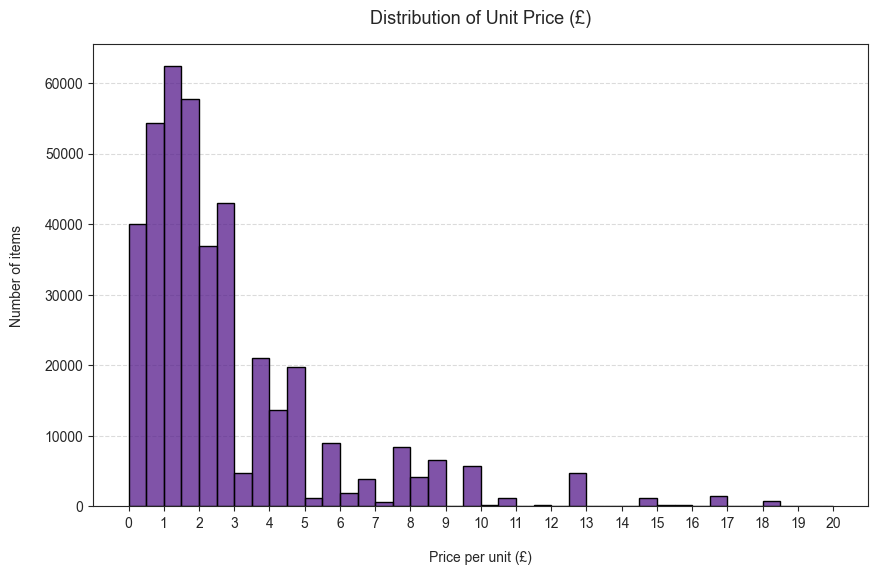

In [37]:
plt.figure(figsize=(10,6))

plt.grid(axis='y',linestyle='--',alpha=0.7)

sns.histplot(data=ecommerce_cleaned,
            x='UnitPrice',
            color="#551A8B",
            edgecolor="black",
            bins=40,
            binrange=(0,20))

plt.xticks(np.arange(0, 21, 1))

plt.title("Distribution of Unit Price (£)",fontsize=13, pad=15)
plt.xlabel("Price per unit (£)", labelpad=15)
plt.ylabel("Number of items", labelpad=15)

plt.show()

`OBSERVATIONS`

* The business `primarily sells low-cost items`, with most products priced within a narrow range of `£1-£3`, indicating a focus on affordable or frequently purchased goods
* A small number of higher priced items exist but contribute less to overall transaction volume
* The pricing structure suggests a `low-price, high-volume business model`
* The distribution is highly right-skewed, indicating the presence of a few expensive products that extend the price range

#### Distribution of Quantity

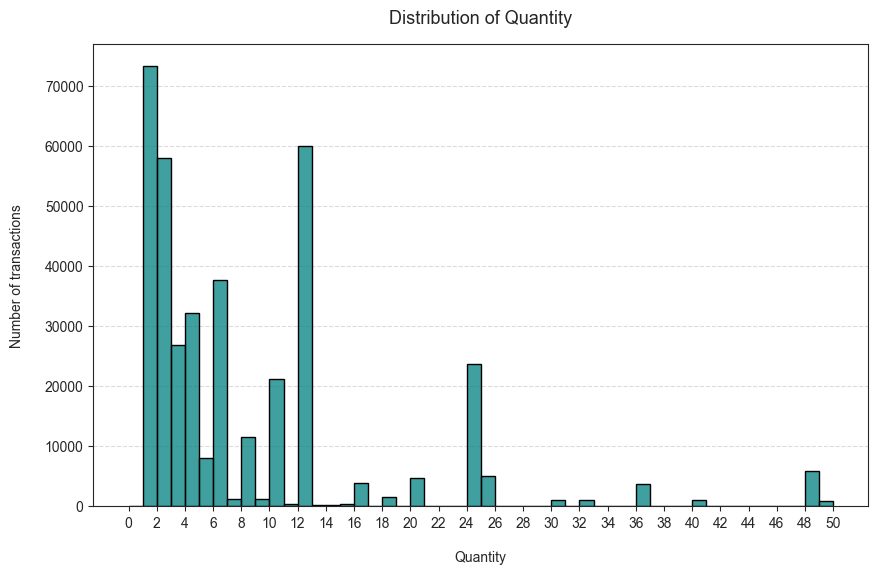

In [38]:
plt.figure(figsize=(10,6))

plt.grid(axis='y',linestyle='--',alpha=0.7)

sns.histplot(data=ecommerce_cleaned,
            x='Quantity',
            color="#008080",
            edgecolor="black",
            bins=50,
            binrange=(0,50))

plt.xticks(np.arange(0, 51, 2))

plt.title("Distribution of Quantity",fontsize=13, pad=15)
plt.xlabel("Quantity", labelpad=15)
plt.ylabel("Number of transactions", labelpad=15)

plt.show()

`OBSERVATIONS`

* The majority of transactions involve small quantities, primarily between 1 and 6 items per order, with a peak around lower values.
* The distribution is heavily right-skewed, with a long tail extending towards higher quantities
* The overall distribution suggests a mixed purchasing behavior, where retail customers contirbute to a higher number of transactions with smaller quantities, while wholesale customers contribute through fewer but large-volume purchases
* The sharp peaks at multiples of 12 suggests that a significant portion of the customer base consists of `small businesses (B2B)` who purchase inventory in standardized case sizes
* This pattern aligns with the dataset description, confirming the presence of both `retail (B2C)` and `wholesale (B2B)` purchasing behavior within the business

### Data Cleaning

### 1) Handling cancellation transactions (Negative Quantity)

#### Invoice Type Identification

In [39]:
ecommerce_cleaned['InvoiceNo'].astype(str).str[0].value_counts()

InvoiceNo
5    397924
C      8905
Name: count, dtype: int64

`OBSERVATION`

* The dataset contains invoice numbers that are either numeric or prefixed with "C"
* Numeric invoice numbers represent standard purchase transactions, while invoices starting with "C" indicate cancellations
* No other invoice prefixes are observed, confirming that cancellations are the only special transaction type present

#### Identification of Cancelled Transactions

In [40]:
ecommerce_cleaned[ecommerce_cleaned['Quantity'] < 0].head()

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom


`OBSERVATION`

* The dataset contains transactions with negative quantities, where invoice numbers start with 'C'

`INSIGHT`

* These entries represent product cancellations and do not reflect actual purchases

`ACTION`

* Negative quantity transactions will be removed to ensure accurate analysis of customer purchasing behaviour and revenue
* Verification needs to be done to ensure that the total sum of negative quantity matches with the cancelled transactions

#### Validation of cancellation transactions

#### Total sum of negative quantity

In [41]:
ecommerce_cleaned[ecommerce_cleaned['Quantity'] < 0]['Quantity'].sum()

np.int64(-274808)

#### Total sum of negative quantity for Invoices that starts with "C"

In [42]:
ecommerce_cleaned[
    ecommerce_cleaned['InvoiceNo'].astype(str).str.startswith('C')
    ]['Quantity'].sum()

np.int64(-274808)

`OBSERVATION`

* The total sum of negative quantities in the dataset is -2,74,808
* The total sum of quantities for invoices starting with "C" is also -2,74,808

`INSIGHT`

* This confirms that all the negative quantity transactions are associated with invoices prefixed with "C", indicating cancellations
* No negative quantities are present in standard transactions

`ACTION`

* Therefore, these transactions are safely removed without losing valid sales data 


#### Removal of cancellation transactions

In [43]:
ecommerce_cleaned = ecommerce_cleaned[ecommerce_cleaned['Quantity'] > 0]

#### Validation after removal

In [44]:
ecommerce_cleaned.shape

(397924, 8)

The updated dataset contains 3,97,924 rows and 8 columns after removing cancellation transactions

### 2) Handling zero unit price transactions

#### Count of zero unit price records

In [45]:
(ecommerce_cleaned['UnitPrice'] == 0).sum()

np.int64(40)

`OBSERVATION`

* The dataset contains a small number of transactions (40 records) where the unit price is zero

#### Inspection of zero unit price records

In [46]:
ecommerce_cleaned[ecommerce_cleaned['UnitPrice'] == 0].head(40)

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410,United Kingdom


`INSIGHTS`

* These transactions likely represent promotional items, free goods, or adjustments included within customer orders
* Since the unit price is zero, these entries do not contribute to revenue and may artificially inflate purchase frequency
* Including such records could distort customer behaviour analysis and lead to inaccurate insights, particularly in revenue-based metrics

`ACTION`

* Transactions with zero unit price are removed to ensure accurate analysis of revenue, customer value, and purchasing behaviour across all objectives

#### Removal of zero unit price records

In [47]:
ecommerce_cleaned = ecommerce_cleaned[ecommerce_cleaned['UnitPrice'] > 0]

#### Validation after removal

In [48]:
(ecommerce_cleaned['UnitPrice'] == 0).sum()

np.int64(0)

### 3) Handling duplicated records

#### Count of duplicated records

In [49]:
ecommerce_cleaned.duplicated().sum()

np.int64(5192)

`OBSERVATION`

* The dataset contains 5,192 duplicated records

#### Verification of duplicated records

In [50]:
ecommerce_cleaned[
    ecommerce_cleaned.duplicated(keep=False)
].sort_values(by=['InvoiceNo','ProductCode']).head(10)

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920,United Kingdom


#### Removal of duplicated records

In [51]:
ecommerce_cleaned = ecommerce_cleaned.drop_duplicates()

#### Validation after removal

In [52]:
ecommerce_cleaned.duplicated().sum()

np.int64(0)

### Feature Engineering

#### Creation of Revenue feature

In [53]:
ecommerce_cleaned['Revenue'] = ecommerce_cleaned['Quantity'] * ecommerce_cleaned['UnitPrice']

#### Validation of Revenue feature

In [54]:
ecommerce_cleaned[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


#### Summary statistics

In [55]:
ecommerce_cleaned['Revenue'].describe()

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

`OBSERVATIONS`

* The majority of revenue values are relatively low with median revenue at 12.45 and 75% of transactions are below 19.80
* The distribution is highly right-skewed, with a maximum value of 1,68,469 indicating the presence of very large transactions

`INSIGHTS`

* Most transactions generate low revenue, reinforcing the business model of low-value, high-frequency purchases
* The presence of extremely high values suggests bulk or wholesale transactions, consistent with earlier observations from quantity analysis
* The strong skew indicates a mix of regular retail customers and high-volume buyers

### Understanding RFM Analysis

RFM is a customer segmentation technique used to understand customer behaviour based on three key metrics:

1) Recency - How recently a customer purchased

* Lower value - Active customer
* Higher value - Inactive customer 

2) Frequency - How often a customer purchase

* High frequency - Loyal customer
* Low frequency - Occasional customer

3) Monetary - How much money a customer spend

* High monetary - High-value customer
* Low monetary - Low-value customer

RFM helps understand customer value using time, purchase frequency, and spending behaviour

#### Goal of RFM

For each CustomerID we want recency, frequency and monetary

Current data - Transaction-level (many rows per customer)

After RFM conversion

New data - Customer-level (one row per customer)

### Recency Calculation

#### Defining reference date

A reference date is required for recency calculation

* Recency = Reference Date (Today date)- Last Purchase Date

Since the dataset is old we assume,

* Reference Date (Today date) = one day after last transaction

In our data:

* Last purchased date: Dec 09
* Reference date: Dec 10

Recency = 1 day

* Customer A last bought: Dec 09 (Dec 10 - Dec 09) - Recency = 1 day (This is an active customer who shopped on the very last day of the records)
* Customer B last bought: Dec 02 (Dec 10 - Dec 02) - Recency = 8 days (This customer shopped exactly one week before the last recorded date)
* Customer C last bought: Nov 10 (Dec 10 - Nov 10) - Recency = 30 days (This customer hasn't shopped in a full month)



In [56]:
reference_date = ecommerce_cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)

In [57]:
reference_date

Timestamp('2011-12-10 12:50:00')

#### Importance of the Reference Date in RFM analysis

* The reference date acts as a universal clock, ensuring every customer is measured against the same fixed point in time for a fair comparison
* Recency is a measure of duration, not a date.
* It provides the necessary starting number to transform specific calendar dates into a measurable number of days (duration)
* Setting the reference date to one day after the latest transaction avoids zero or negative recency values, ensuring consistency in calculations and scoring 

#### Calculating Recency for each Customer

How many days since each customer's last purchase?

* Low recency = Active customer
* High recency = Inactive customer

In [58]:
recency = ecommerce_cleaned.groupby('CustomerID')['InvoiceDate'].max().reset_index()

In [59]:
recency['Recency'] = (reference_date - recency['InvoiceDate']).dt.days

In [60]:
recency.head()

,CustomerID,InvoiceDate,Recency
0,12346,2011-01-18 10:01:00,326
1,12347,2011-12-07 15:52:00,2
2,12348,2011-09-25 13:13:00,75
3,12349,2011-11-21 09:51:00,19
4,12350,2011-02-02 16:01:00,310


`INSIGHTS`

* Customers with low recency values are highly engaged and recently active
* Customers with high recency values have not made purchases for a long time and may be at risk of churn

1) `Customer 12347`: Recency = 2 (Bought very recently, `High active customer`)
3) `Customer 12349`: Recency = 19 (Bought a few weeks ago, `Moderately active customer`)
4) `Customer 12346`: Recency = 326 (Bought a long time ago, `Inactive customer / Churn risk`)

#### Removal of InvoiceDate column from Recency Data

In [61]:
recency = recency.drop(columns=['InvoiceDate'])

In [62]:
recency.head()

,CustomerID,Recency
0,12346,326
1,12347,2
2,12348,75
3,12349,19
4,12350,310


### Frequency Calculation

#### Calculating Frequency for each Customer

How many times did a customer buy?

Frequency = Number of unique invoices per customer

* One unique invoice = one purchase
* One unique invoice can have multiple rows (products)

So if one unique invoice has 5 product purchases, the frequency will be 1, not 5

* High frequency = Loyal customer
* Low frequency = Occasional customer

In [63]:
frequency = ecommerce_cleaned.groupby('CustomerID')['InvoiceDate'].nunique().reset_index()

In [64]:
frequency.columns = ['CustomerID', 'Frequency']

In [65]:
frequency.head()

,CustomerID,Frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1


`INSIGHTS`

* Customers with high frequency values indicate repeated purchases and stronger engagement with the business
* Customers with low frequency values represent one-time or occasional buyers

1) `Customer 12347`: Frequency = 7 (`Loyal customer` with multiple purchases)
2) `Customer 12348`: Frequency = 4 (`Moderately engaged customer`)
3) `Customer 12346`: Frequency = 1 (`One-time or low-engagement customer`)

### Monetary Calculation

#### Calculating Monetary for each Customer

How much money each customer has spent?

This answers:

* How valuable a customer is to this business
* Total revenue generated by each customer

Monetary = Sum of Revenue per customer

* Higher monetary = High-value customer
* Lower monetary = Low-value customer

In [66]:
monetary = ecommerce_cleaned.groupby('CustomerID')['Revenue'].sum().reset_index()

In [67]:
monetary.columns = ['CustomerID', 'Monetary']

In [68]:
monetary.head()

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


`INSIGHTS`

* Customers with higher monetary values contribute significantly to overall business revenue
* Customers with lower monetary values represent low-value or occasional buyers

1) `Customer 12346`: Monetary = 77,183.60 (`Very high-value customer`)
2) `Customer 12347`: Monetary = 4310 (`High-value customer`)
3) `Customer 12348`: Monetary = 1797.24 (`Mid-value customer`)
4) `Customer 12350`: Monetary = 334.40 (`Low-value customer`)

### Creating RFM Dataset

RFM analysis requires all three metrics together for each customer

A merge function is used to join tables on CustomerID

In [69]:
rfm = recency.merge(frequency, on='CustomerID')

In [70]:
rfm = rfm.merge(monetary, on='CustomerID')

In [71]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


`INSIGHTS`

* Customers with low recency, high frequency, and high monetary values represents the most loyal and valuable customers
* Customers with high recency and low frequency indicate inactivity and potential churn risk
* Customers with high monetary but low recency represent previously valuable customers who are no longer active

1) Customer 12347

* Recency = 2, Frequency = 7, Monetary = 4310 `Best customer (active, loyal, valuable)`

2) Customer 12348

* Recency = 75, Frequency = 4, Monetary = 1797.24 `Moderate customer (Engaged but not very recent)`

3) Customer 12346

* Recency = 326, Frequency = 1, Monetary = 77183 `High spender but inactive customer`

4) Customer 12350

* Recency = 310, Frequency = 1, Monetary = 334.40 `Low-value inactive customer`

RFM combines time, behaviour, and value into one powerful customer profile

#### Summary statistics

In [72]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.250807,2048.688081
std,1721.808492,100.014169,7.635202,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,210.000000,280206.020000


`OBSERVATIONS`

* The RFM dataset contains 4,338 customers
* Recency values range from 1 to 374 days, indicating varying levels of customer activity
* Frequency values ranges from 1 to 210 purchases, showing differences in customer engagement
* Monetary values ranges from 3.75 to 2,80,206 indicating a wide variation in customer spending

`INSIGHTS`

* The wide spread in Recency suggests both active and inactive customer segments exist within the dataset
* The high maximum values in Frequency and Monetary indicate the presence of highly loyal and high-spending customers

### RFM Scoring

The current raw values of Recency, Frequency, and Monetary are on a different scale

* Recency - 1 to 374
* Frequency - 1 to 210
* Monetary - 3.75 to 2,80,206

These cannot be used to directly compare customers

Hence, these values are converted into ranked scores (1 to 4)

#### Why RFM Scoring is needed?

* Raw values are converted into ranked scores (1 to 4)
* This allows customers to be compared relative to each other
* Absolute values are replaced with relative values

`RFM Scoring is used to convert raw values into ranked scores to segment customers`

#### Scoring method

Customers are divided into four groups:

* Bottom 25% - Score 1 (Worst)
* Next 25% - Score 2 (Average)
* Next 25% - Score 3 (Good)
* Top 25% - Score 4 (Best)

Quantiles are used to divide the data into equal-sized groups

#### Scoring criteria

`RECENCY`

* Low recency - Score 4
* High recency - Score 1

`FREQUENCY`

* High frequency - Score 4
* Low frequency - Score 1

`MONETARY`

* High Monetary - Score 4
* Low Monetary - Score 1

Example

* 444 - Best customers
* 321 - Moderate customers
* 111 - Low-value customers

#### How qcut actually splits the data?

`qcut ()` splits the data into equal-sized groups based on sorted values

* Step 1: Sorting the values smallest to largest
* Step 2: Split into four equal groups
* 1st 25% - Lowest values (Bottom group)
* 2nd 25% - Low-mid
* 3rd 25% - Mid-high
* 4th 25% - Highest values (Top group)

The groups are always formed from lowest (bottom 25%) and moves upward

* If Low value is good, labels = [4, 3, 2, 1]
* If High value is good, labels = [1, 2, 3, 4]

`qcut ()` creates groups, but the labels decides which group is good or bad

#### Assigning Recency Scores using Quantiles

In [73]:
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])

In [74]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R
0,12346,326,1,77183.60,1
1,12347,2,7,4310.00,4
2,12348,75,4,1797.24,2
3,12349,19,1,1757.55,3
4,12350,310,1,334.40,1


In [75]:
rfm['R'].value_counts()

R
4    1125
1    1084
2    1066
3    1063
Name: count, dtype: int64

#### Assigning Frequency Scores using Quantiles

In [76]:
rfm['F'] = pd.qcut(rfm['Frequency'], 4, duplicates='drop')

In [77]:
rfm['F'] = rfm['F'].cat.codes + 1

In [78]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F
0,12346,326,1,77183.60,1,1
1,12347,2,7,4310.00,4,3
2,12348,75,4,1797.24,2,2
3,12349,19,1,1757.55,3,1
4,12350,310,1,334.40,1,1


In [79]:
rfm['F'].value_counts()

F
1    2328
2    1141
3     869
Name: count, dtype: int64

`ISSUE`

* While assigning frequency scores using quantiles, an error occured due to duplicate values in the Frequency column
* A large number of customers have the same frequency value (especially frequency = 1)
* This caused non-unique bin edges when attempting to split the data into four equal groups
* For example, non-unique bin edges - `[1, 1, 2, 5, 210]` cannot be used to split into four equal groups since two boundaries are same
* As a result, `pd.qcut()` could not create four distinct quantile groups

`SOLUTION`

* To handle this, the `duplicates=drop` parameter was used with `pd.qcut()`
* It removes duplicate bin edges resulting in `[1, 2, 5, 210]` which can be grouped only into three rather than four
* This allows the number of groups to adjust automatically based on the data distribution
* The resulting categorical ranges `(1.0, 2.0, 5.0)` after dropping were converted into scores using `.cat.codes`
* `+1` is added to shift the scores from 0-based to 1-based indexing

`RESULT`

* The frequency values were successfully grouped into 3 segments
* Scores assigned are `1 (Low), 2 (Medium), 3 (High)`

#### Assigning Monetary Scores using Quantiles

In [80]:
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

In [81]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M
0,12346,326,1,77183.60,1,1,4
1,12347,2,7,4310.00,4,3,4
2,12348,75,4,1797.24,2,2,4
3,12349,19,1,1757.55,3,1,4
4,12350,310,1,334.40,1,1,2


In [82]:
rfm['M'].value_counts()

M
1    1085
4    1085
2    1084
3    1084
Name: count, dtype: int64

#### Creating combined RFM Score for Customer Segmentation

In [83]:
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

In [84]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score
0,12346,326,1,77183.60,1,1,4,114
1,12347,2,7,4310.00,4,3,4,434
2,12348,75,4,1797.24,2,2,4,224
3,12349,19,1,1757.55,3,1,4,314
4,12350,310,1,334.40,1,1,2,112


### Customer Segmentation

Customer segmentation is the process of grouping customers based on their behaviour and value to the business

Using the RFM Scores (Recency, Frequency, Monetary), customers can be categorized into different segments such as at-risk, loyal, or high-value customers

Each customer's RFM Score represents their activity level, engagement, and spending behaviour

By combining these scores, patterns can be identified and similar customers are grouped together

This helps businesses:

* Understand different types of customers
* Detect inactive or at-risk customers
* Identify loyal customers
* Find high-value customers
* Create targeted marketing strategies

RFM-based segmentation transforms raw transactional data into meaningful customer groups that support better decision-making

#### Defining customer segments

Defining four groups:

1) `Champions`

* Recency = 4 (High active)
* Frequency = 3 (High frequency)
* Monetary >= 3 (High spending)

Best customers

2) `Loyal Customers`

* Recency >= 3 (Fairly active)
* Frequency >= 2 (Moderate to high frequency)
* Monetary >= 2 (Moderate to high spending)

Regular and valuable customers

3) `At-Risk Customers`

* Recency <= 2 (Inactive)
* Frequency >= 2 (Moderate to high frequency)

Previously active customers who are now inactive

4) `Lost Customers`

* Recency = 1 (Inactive)
* Frequency = 1 (Low frequency)

Inactive and low engagement

* Behaviour - Recency and Frequency (Behaviour matters more for at-risk and lost segments)
* Value - Monetary (Value matters more for champions and loyal segments)

In [85]:
def segment_customer(row):
    if row['R'] == 4 and row['F'] == 3 and row['M'] >= 3:
        return 'Champions'

    elif row['R'] >= 3 and row['F'] >= 2 and row['M'] >= 2:
        return 'Loyalist'

    elif row['R'] <= 2 and row['F'] >= 2:
        return 'At-Risk'

    elif row['R'] == 1 and row['F'] == 1:
        return 'Lost'

    else:
        return "Others"

In [86]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [87]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,4,114,Lost
1,12347,2,7,4310.00,4,3,4,434,Champions
2,12348,75,4,1797.24,2,2,4,224,At-Risk
3,12349,19,1,1757.55,3,1,4,314,Others
4,12350,310,1,334.40,1,1,2,112,Lost


In [88]:
rfm['Segment'].value_counts()

Segment
Others       1401
Lost          946
Loyalist      906
At-Risk       561
Champions     524
Name: count, dtype: int64

`INSIGHTS`

* The business has a strong loyal customer baseand a valuable group of champions
* A large number of lost customers indicates retention challenges
* The presence of at-risk customers highlights opportunities for re-engagement
* The large "Others" segment suggests potential for refining segmentation logic 

#### Average behaviour of customer segments

In [89]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(1)

In [90]:
print(segment_summary.sort_values(by='Monetary', ascending=False))

           Recency  Frequency  Monetary  CustomerID
Segment                                            
Champions      7.5       15.0    8472.2         524
Loyalist      23.4        5.3    2320.4         906
At-Risk      113.3        4.5    1764.1         561
Others        52.2        1.5     643.8        1401
Lost         253.2        1.2     479.7         946


`INSIGHTS`

1) The champions make up only about 12% of the customers, but with an average spend of 8,472, they likely contribute nearly half of the total revenue. This proves that a small group of users drives the majority of business value
2) Loyalist shop every 23 days, while At-Risk haven't shopped in 113 days
3) There is a massive gap between Loyalist (23 days since last purchase) and At-Risk customers (113 days). This suggests that if a Loyalist doesn't return within 30-45 days, the probability of them becoming "At-Risk" increases significantly
4) The Others group (1,401) has a frequency of 1.5. This indicates that most people in this segment bought once and never came back.
5) The At-Risk segment has a high average of 1,764. These aren't cheap customers rather they are high-value customers that the business is currently losing

#### Refining segmentation by adding New Customer and Hibernating groups

The segmentation is updated by splitting `Others` into two new groups:

1) `New Customer`

* Recency = 4
* Frequency = 1

They are the future of the business

2) `Hibernating`

* Recency = 2, 3
* Frequency = 1

They tried the brand months ago and never came back

In [91]:
def refined_segmentation(row):
    if row['R'] == 4 and row['F'] == 3 and row['M'] >= 3:
        return 'Champions'

    elif row['R'] >= 3 and row['F'] >= 2 and row['M'] >= 2:
        return 'Loyalist'

    elif row['R'] <= 2 and row['F'] >= 2:
        return 'At-Risk'

    elif row['R'] == 4 and row ['F'] == 1:
        return 'New Customer'

    elif (row['R'] == 3 or row['R'] == 2) and row['F'] == 1:
        return 'Hibernating'

    elif row['R'] == 1 and row['F'] == 1:
        return 'Lost'

    else:
        return "Hibernating"

In [92]:
rfm['Segment'] = rfm.apply(refined_segmentation, axis=1)

In [93]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,4,114,Lost
1,12347,2,7,4310.00,4,3,4,434,Champions
2,12348,75,4,1797.24,2,2,4,224,At-Risk
3,12349,19,1,1757.55,3,1,4,314,Hibernating
4,12350,310,1,334.40,1,1,2,112,Lost


In [94]:
rfm['Segment'].value_counts()

Segment
Hibernating     1132
Lost             946
Loyalist         906
At-Risk          561
Champions        524
New Customer     269
Name: count, dtype: int64

`INSIGHTS`

* Hibernating represents the largest customer group (1,132)
* This significantly exceeds the New Customer count which is 269
* For every 1 brand new customer that walks in the door, 4 existing customers are falling asleep
* The business might be spending money to get new people, but it isn't doing enough to keep them

#### Average behaviour after updating customer segments

In [95]:
refined_segment_summary = rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(1)

In [96]:
print(refined_segment_summary.sort_values(by='Monetary', ascending=False))

              Recency  Frequency  Monetary  CustomerID
Segment                                               
Champions         7.5       15.0    8472.2         524
Loyalist         23.4        5.3    2320.4         906
At-Risk         113.3        4.5    1764.1         561
New Customer      9.8        1.6    1125.0         269
Hibernating      62.3        1.4     529.5        1132
Lost            253.2        1.2     479.7         946


#### Customer lifecycle between the segments

The Success Path

* `New Customer` -> `Loyalist` - A New Customer (recency of 9.8 days) has a frequency of 1.6. If they shop again soon, they cross the habit threshold (moving to 5.3) and become a Loyalist
* `Loyalist` -> `Champions` - Once a Loyalist (Frequency of 5.3) starts shopping even more frequently (reaching frequency of 15.0) and spending more (8k+), they become a Champion

The Churn Path

* `New Customer` -> `Hibernating` - If a New Customer doesn't buy again within roughly 30 days, they do direcly into Hibernating. This is why the Hibernating group is so large. The company is having a hard time converting New Customers into a Loyalist
* `Loyalist` -> `At-Risk` - When a Loyalist stops shopping for more than 90 days, they lose their Loyalist status and moves into At-Risk

The Final Exit

* `Hibernating/At-Risk -> Lost` - If the business fails to wake up the Hibernating or At-Risk group, they eventually cross the 250-day mark. Once recency exceeds 250 days, the probabililty of re-engagement drops to near zero, and the customer is considered Lost

#### Percentage share of Segments

In [100]:
segment_counts = rfm['Segment'].value_counts()
segment_percentage = (rfm['Segment'].value_counts(normalize=True) * 100).round(1)

In [101]:
segment_percentage

Segment
Hibernating     26.1
Lost            21.8
Loyalist        20.9
At-Risk         12.9
Champions       12.1
New Customer     6.2
Name: proportion, dtype: float64

`INSIGHTS`

* Hibernating (26.1%) and Lost (21.8%) together make up 47.9% of the entire data. This means nearly half of the people who have ever shopped are currently not active
* Champions (12.1%) and Loyalist (20.9%) together make up 33% of the customer base. This portion of customers is providing almost all of the current revenue
* New customers make up only about 6.2% of the entire data. This confirms that the business is not bringing in new people as fast as they are losing the old ones

### Data Visualization

#### Customer Segment Volume Analysis using Treemap

In [228]:
df = rfm['Segment'].value_counts().rename_axis('Segment').reset_index(name='Count')

total_customers = rfm['CustomerID'].nunique()

In [219]:
color_map = {
    'Champions': '#1B9E77',
    'Loyalist': '#2ECC71',
    'New Customer': '#F39C12',
    'At-Risk': '#C0392B',
    'Hibernating': '#E74C3C',
    'Lost': '#7F8C8D'
}

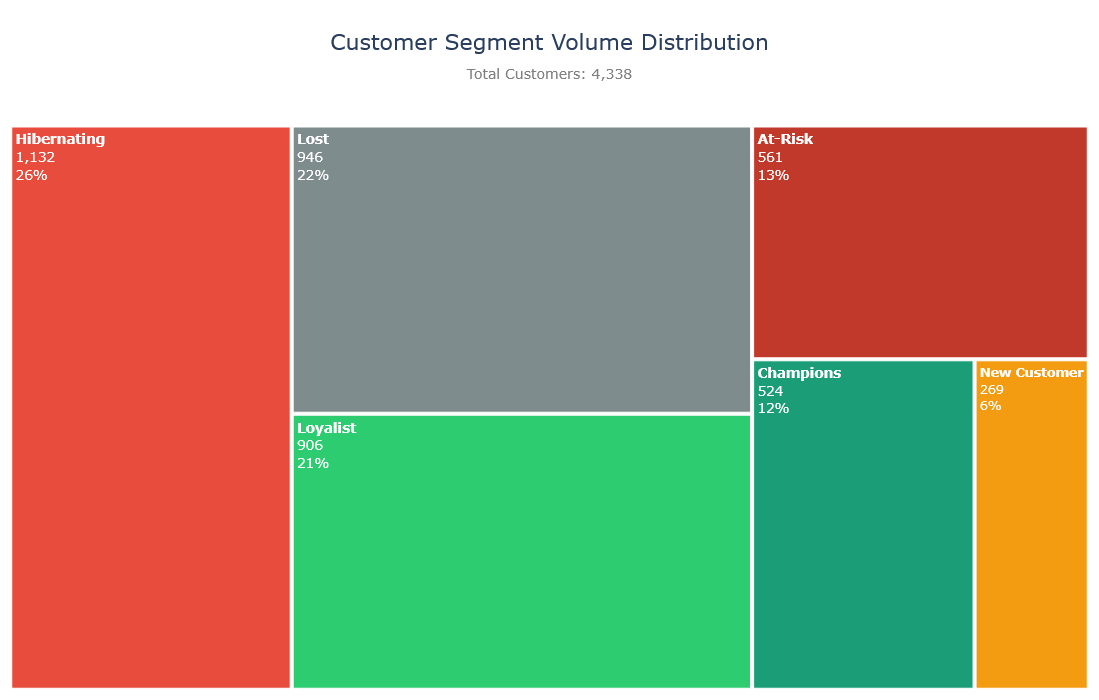

In [241]:
fig = px.treemap(
    df,
    path=['Segment'],
    values='Count',
    title='Customer Segment Distribution',
    color='Segment',
    color_discrete_map=color_map,
    template='plotly_white'
)

fig.update_traces(
    texttemplate="<b>%{label}</b><br>%{value:,}<br>%{percentRoot:.0%}",
    hovertemplate=None,
    hoverinfo="skip",
    textfont=dict(color="white", size=13.5)
)

fig.update_layout(
    title={
        'text': f"Customer Segment Volume Distribution<br><span style='font-size:14px; color:gray;'>Total Customers: {total_customers:,}</span>",
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=22)},
    width=900,
    height=700,
    margin=dict(t=100, l=5, r=5, b=5),
)

fig.show()

`INSIGHTS`

Inactive (Red/Gray)

* Nearly half (48%) of the entire customer base is currently inactive
* The massive size of the Red and Gray boxes shows that the business is losing customers faster than it keeps them.
* Most people buy once and never return.
* This suggests that the first-purchase experience is not strong enough to create a habit
* For every 1 new person who joins, 4 people are moving into the Hibernating category
* The At-Risk group (13%) is roughly the same size as the Champions (12%).
* This group is the highest priority for intervention. They used to be loyal but haven't shopped in a long time

Active (Green)

* Loyalist (21%) make up the largest group of active customers
* While they don't spend much as much as champions, their large volume (906) people makes them the most important group for consistent revenue

Growth (Orange)

* New Customer represents only 6% of the total customer base. The inflow of new people is very small compared to the outflow of people leaving.

#### Why is the At-Risk segment not in the Inactive category?

1) Lost (22%) - The dead segment

* Status: Inactive
* These customers haven't shopped in about 250+ days
* They are considered churned and gone

2) Hibernating (26%) - The sleeping segment

* Status: Inactive
* These cusomers haven't shopped in about 60-100 days
* While they are technically inactive right now, they are sleeping, not dead
* There is still a chance to wake them up

3) At-Risk (13%) - The warning segment

* Status: Semi-Active
* They aren't fully inactive yet, but their recency is dropping
* They are in the danger zone
* They aren't considered in the 48% because they are semi-active customers who aren't fully active, but these customers are headed to the inactive category if no proper business plans are done to bring them back

#### Average Monetary Value by Segment using Bar chart

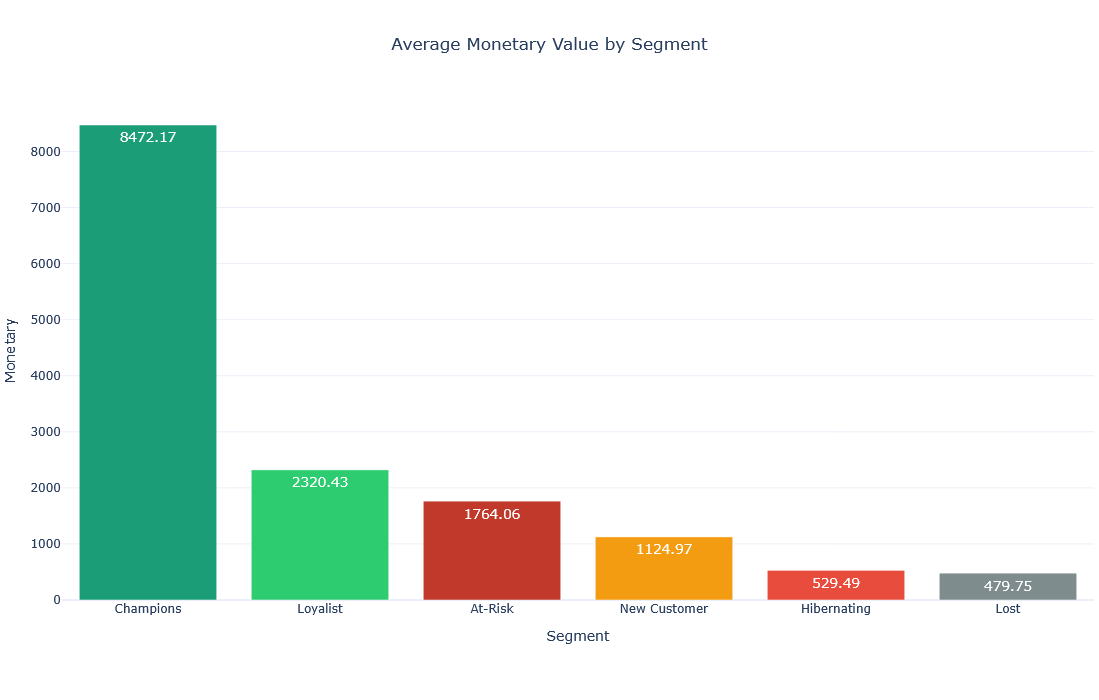

In [265]:
fig = px.bar(
    rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False).reset_index(),
    x='Segment',
    y='Monetary',
    title='Average Monetary Value by Segment',
    color='Segment',
    color_discrete_map=color_map,
    text_auto='.2f',
    template='plotly_white'
)

fig.update_traces(
    hovertemplate=None,
    hoverinfo="skip",
    textfont=dict(color="white", size=13.5)
)

fig.update_layout(
    title_x=0.5,
    showlegend=False,
    width=900,
    height=700,
    margin=dict(t=100, l=5, r=5, b=100),
)

fig.show()